In [51]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib


In [52]:
df = pd.read_excel("excel1.xlsx")

print(df.head())
print(df.info())


  Source_material Alkali_solution  Molarity  SS_SH_KOH_ratio A_B_ratio  \
0            F. A           SS/SH        10              1.0        --   
1            F. A           SS/SH        10              1.0      0.15   
2            F. A           SS/SH        15              2.0      0.26   
3            F. A           SS/SH        14              2.5      0.35   
4            F. A           SS/SH        14              2.0       0.4   

  Curing_temp Compression_28d  
0       35-40           35.29  
1       35-40            37.4  
2          80            22.4  
3          60              60  
4          90              --  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Source_material  113 non-null    object 
 1   Alkali_solution  113 non-null    object 
 2   Molarity         113 non-null    int64  
 3   SS_SH_KOH_ratio  113 non

In [53]:
# Remove spaces & fix string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Replace junk values with NaN
df = df.replace(["--", "-", "—", ""], np.nan)


In [54]:
def fix_curing_temp(val):
    if isinstance(val, str) and "-" in val:
        a, b = val.split("-")
        return (float(a) + float(b)) / 2
    return val

df["Curing_temp"] = df["Curing_temp"].apply(fix_curing_temp)


In [55]:
numeric_cols = [
    "Molarity",
    "SS_SH_KOH_ratio",
    "A_B_ratio",
    "Curing_temp",
    "Compression_28d"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [56]:
TARGET = "Compression_28d"

# Drop rows with missing target
df = df.dropna(subset=[TARGET])

X = df.drop(columns=[TARGET])
y = df[TARGET]


In [57]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns


In [58]:
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])


In [59]:
label_encoders = {}

for col in categorical_cols:
    X[col] = X[col].astype(str)
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Optional check
label_encoders["Alkali_solution"].classes_


array(['SS/ KOH', 'SS/SH', 'SS/SH/25%KOH'], dtype=object)

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [62]:
from xgboost import XGBRegressor


models = {
    "LinearRegression": LinearRegression(),
    "RidgeRegression": Ridge(alpha=1.0),
    "SVR": SVR(kernel="rbf"),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
}


In [63]:
!pip install xgboost


[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: C:\Users\nawfa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [64]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    results[name] = {
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds))
    }
    
    joblib.dump(model, f"{name}_model.pkl")


Training LinearRegression...
Training RidgeRegression...
Training SVR...
Training RandomForest...
Training GradientBoosting...
Training XGBoost...


In [65]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(num_imputer, "num_imputer.pkl")
joblib.dump(cat_imputer, "cat_imputer.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")


['label_encoders.pkl']

In [66]:
results_df = pd.DataFrame(results).T
results_df


,R2,MAE,RMSE
LinearRegression,0.243173,11.280381,12.910112
RidgeRegression,0.242020,11.276851,12.919940
SVR,0.234060,9.154255,12.987605
RandomForest,0.483522,7.236005,10.664914
GradientBoosting,0.613010,6.546502,9.231698
XGBoost,0.395380,7.707206,11.539128


In [67]:
# Load best model (example: RandomForest)
model = joblib.load("RandomForest_model.pkl")

scaler = joblib.load("scaler.pkl")
label_encoders = joblib.load("label_encoders.pkl")

sample = pd.DataFrame([{
    "Source_material": "F. A",
    "Alkali_solution": "SS/ KOH",
    "Molarity": 14,
    "SS_SH_KOH_ratio": 1.5,
    "A_B_ratio": 0.5,
    "Curing_temp": 90
}])

# Clean input
for col in sample.select_dtypes(include="object").columns:
    sample[col] = sample[col].str.strip()

# Encode
for col, le in label_encoders.items():
    sample[col] = le.transform(sample[col])

# Scale
sample_scaled = scaler.transform(sample)

# Predict
prediction = model.predict(sample_scaled)
print("Predicted 28-day compressive strength:", prediction[0])


Predicted 28-day compressive strength: 81.16552029100542


In [68]:
def plot_actual_vs_pred(y_test, y_pred, model_name):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             linestyle="--")
    plt.xlabel("Actual Compression Strength (28 Days)")
    plt.ylabel("Predicted Compression Strength")
    plt.title(f"{model_name}: Actual vs Predicted")
    plt.grid(True)
    plt.show()


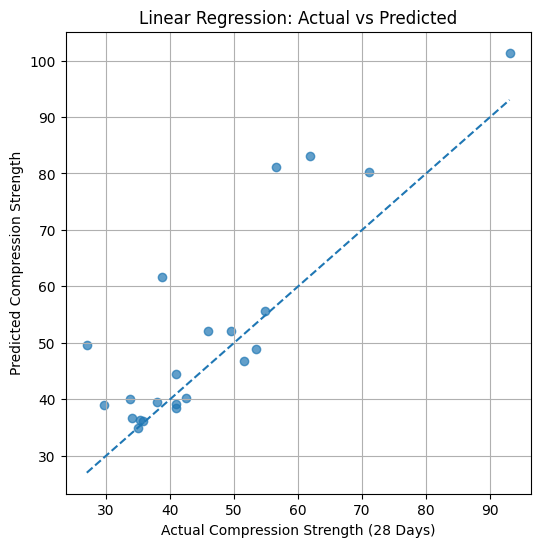

In [69]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = model.predict(X_test)
plot_actual_vs_pred(y_test, y_pred, "Linear Regression")

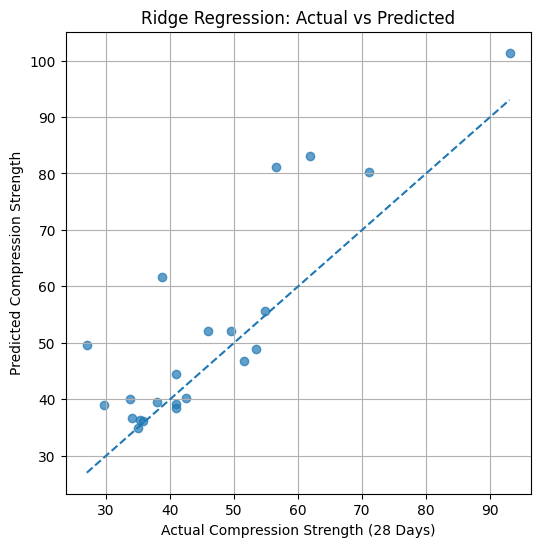

In [70]:
from sklearn.linear_model import Ridge

lr_model = Ridge(alpha=1.0)
lr_model.fit(X_train, y_train)
y_pred = model.predict(X_test)
plot_actual_vs_pred(y_test, y_pred, "Ridge Regression")

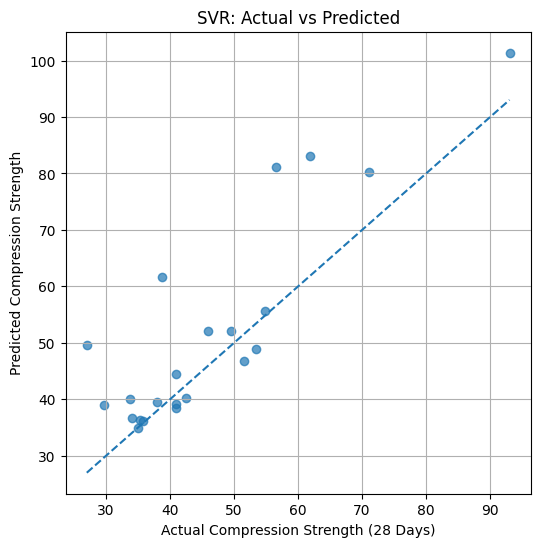

In [71]:

lr_model =  SVR(kernel="rbf")
lr_model.fit(X_train, y_train)
y_pred = model.predict(X_test)
plot_actual_vs_pred(y_test, y_pred, "SVR")

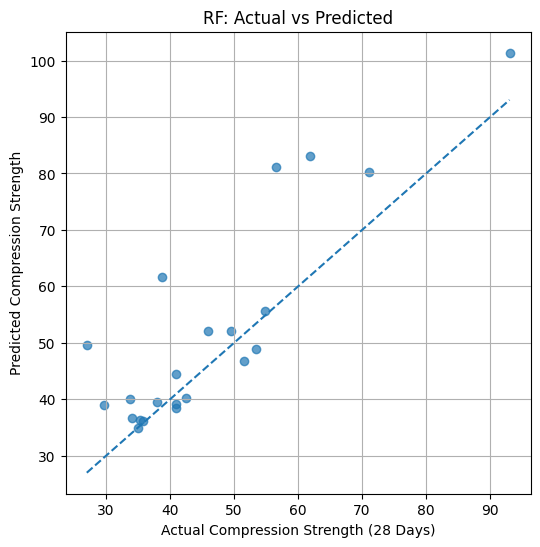

In [72]:

lr_model =RandomForestRegressor(n_estimators=300, random_state=42)
lr_model.fit(X_train, y_train)
y_pred = model.predict(X_test)
plot_actual_vs_pred(y_test, y_pred, "RF")

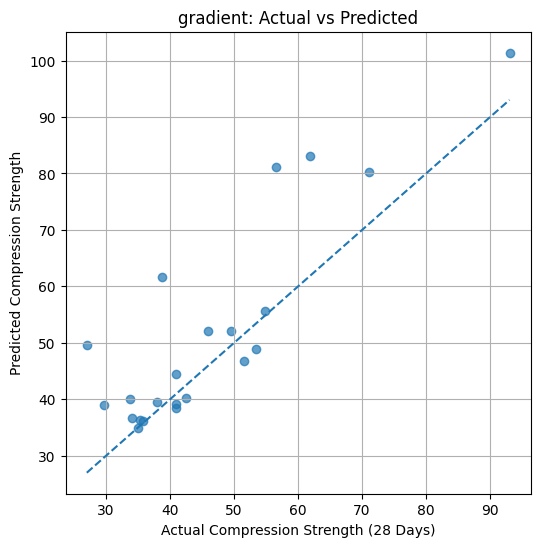

In [73]:

lr_model =GradientBoostingRegressor()
lr_model.fit(X_train, y_train)
y_pred = model.predict(X_test)
plot_actual_vs_pred(y_test, y_pred, "gradient")

## 📊 Extended Exploratory Data Analysis & Visualizations

In [74]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reload original dataframe for EDA (before encoding)
df_eda = pd.read_excel('excel1.xlsx')
for col in df_eda.select_dtypes(include='object').columns:
    df_eda[col] = df_eda[col].astype(str).str.strip()
df_eda = df_eda.replace(['--', '-', '—', ''], float('nan'))

def fix_curing(val):
    if isinstance(val, str) and '-' in val:
        parts = val.split('-')
        try: return (float(parts[0]) + float(parts[1])) / 2
        except: return float('nan')
    return val

df_eda['Curing_temp'] = df_eda['Curing_temp'].apply(fix_curing)
num_cols = ['Molarity', 'SS_SH_KOH_ratio', 'A_B_ratio', 'Curing_temp', 'Compression_28d']
for col in num_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

df_eda.dropna(subset=['Compression_28d'], inplace=True)
print(f'EDA dataset shape: {df_eda.shape}')
df_eda.describe()


EDA dataset shape: (110, 7)


,Molarity,SS_SH_KOH_ratio,A_B_ratio,Curing_temp,Compression_28d
count,110.000000,110.000000,109.000000,110.000000,110.000000
mean,12.154545,2.094000,0.416055,112.836364,49.853000
std,2.793132,0.589172,0.069602,196.897881,20.590191
min,8.000000,1.000000,0.150000,20.000000,20.000000
25%,10.000000,1.500000,0.350000,60.000000,37.025000
50%,12.000000,2.500000,0.450000,70.000000,44.000000
75%,14.000000,2.500000,0.450000,90.000000,55.750000
max,20.000000,3.000000,0.550000,1200.000000,145.300000


### 🔥 1. Correlation Heatmap (Numeric Features)

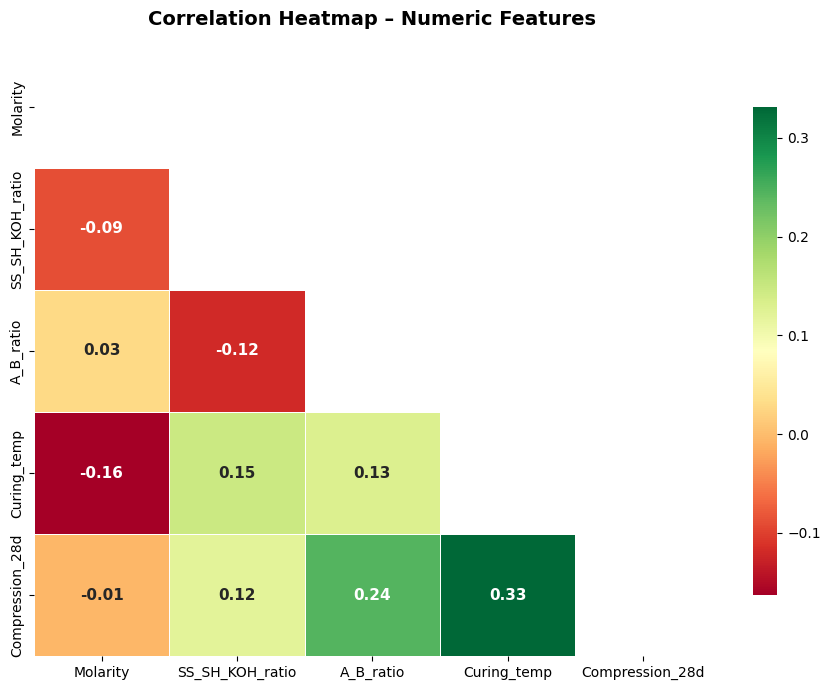

In [75]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df_eda[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Correlation Heatmap – Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### 🔵 2. Pairplot – All Numeric Variables

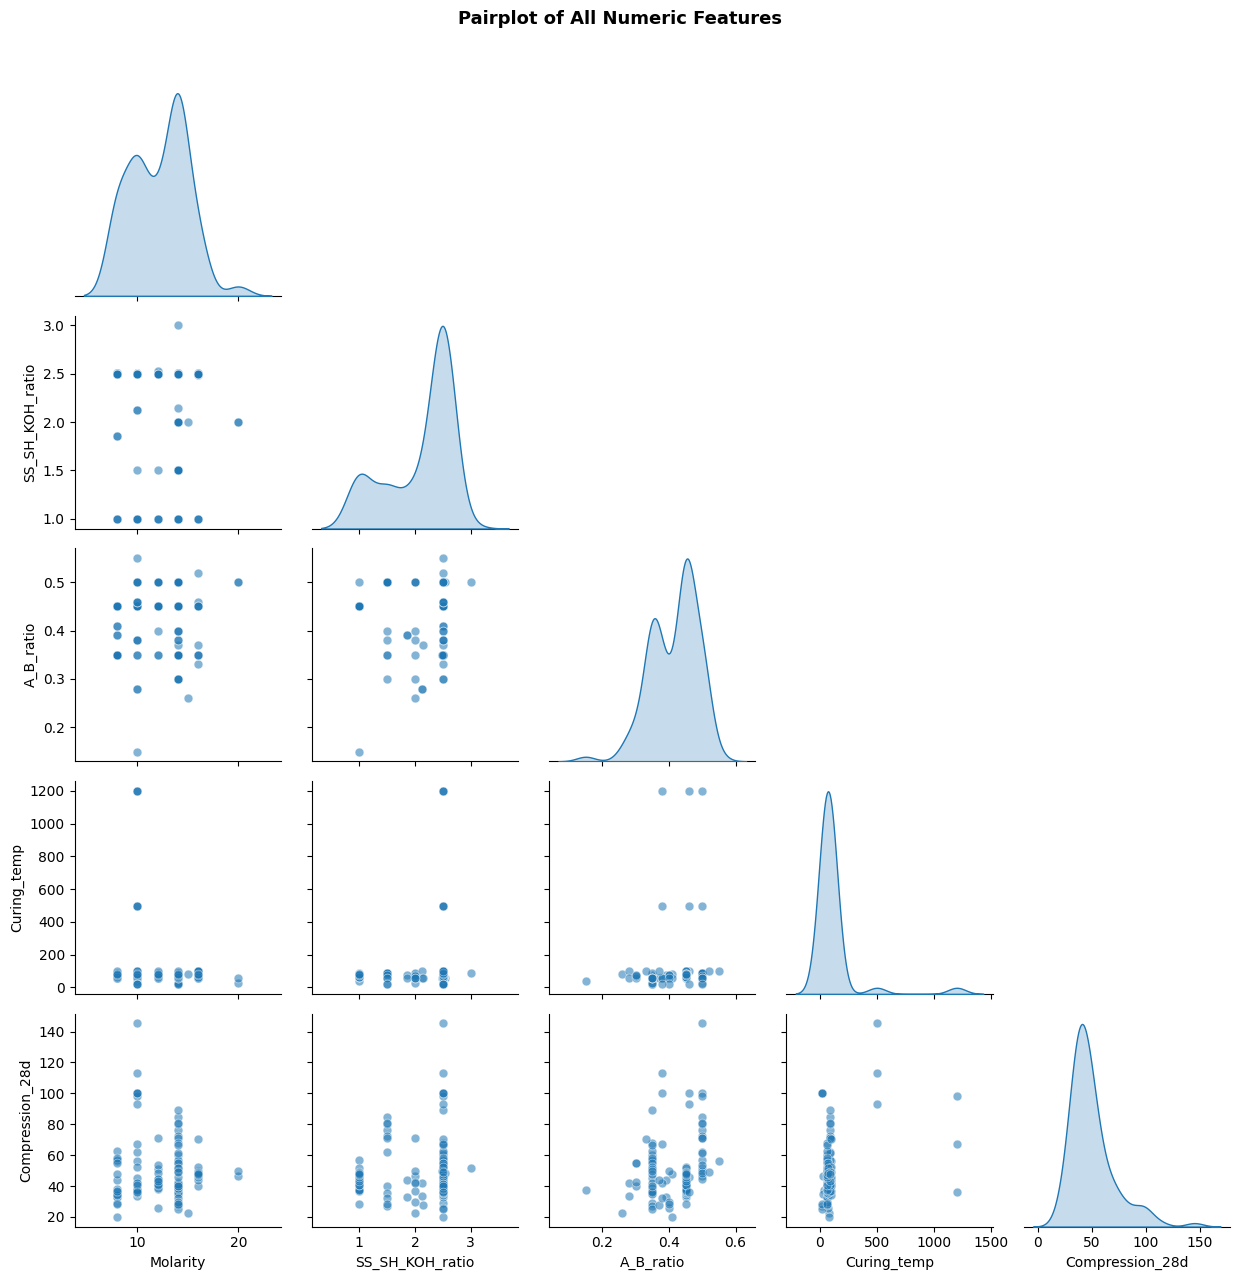

In [76]:
g = sns.pairplot(df_eda[num_cols].dropna(), diag_kind='kde',
                 plot_kws={'alpha': 0.55, 'edgecolors': 'white', 's': 40},
                 diag_kws={'fill': True},
                 corner=True)
g.figure.suptitle('Pairplot of All Numeric Features', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 📈 3. Distribution Histograms (KDE overlay)

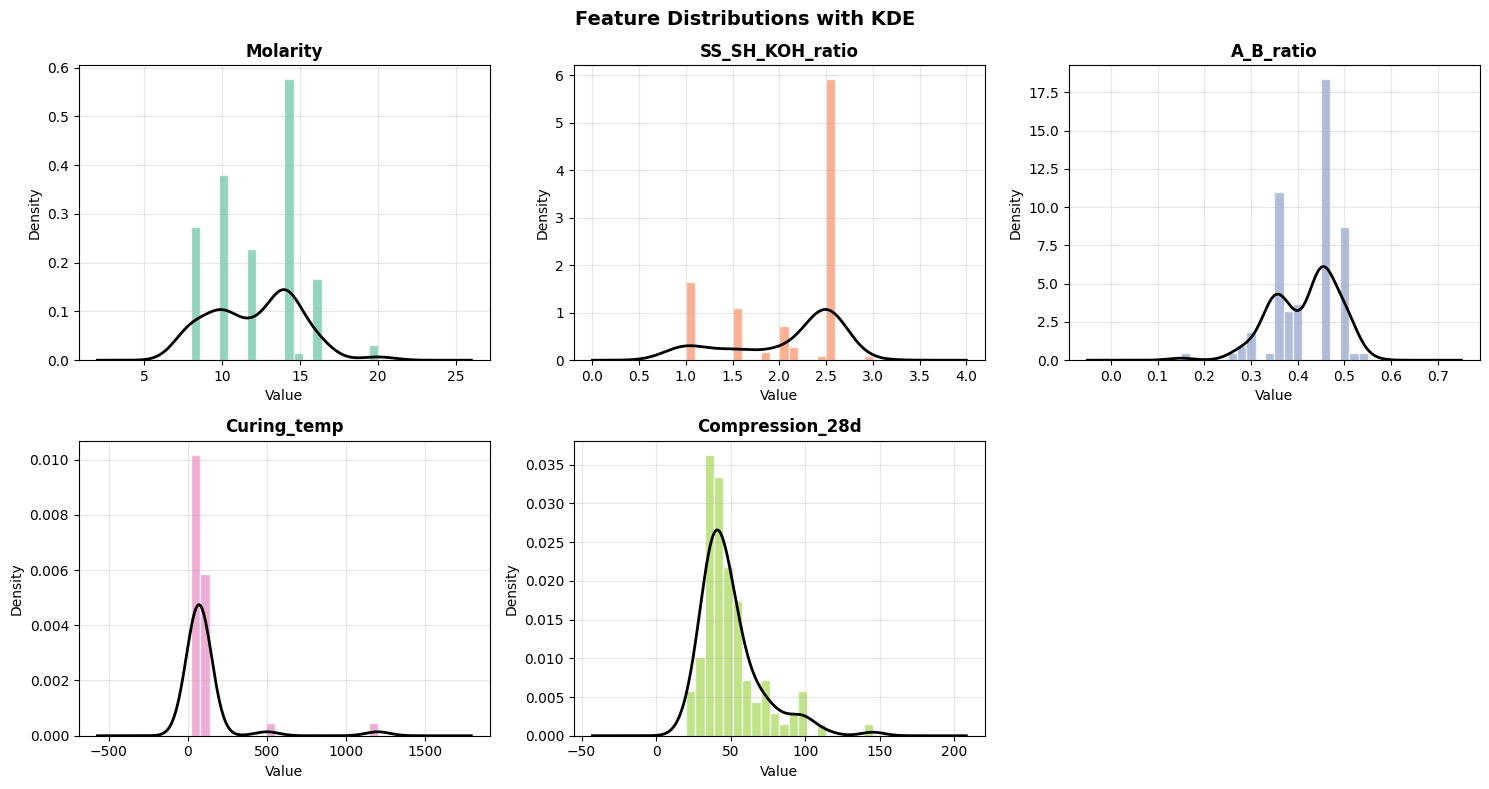

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = sns.color_palette('Set2', len(num_cols))
for i, col in enumerate(num_cols):
    data = df_eda[col].dropna()
    axes[i].hist(data, bins=20, color=colors[i], alpha=0.7, edgecolor='white', density=True)
    data.plot.kde(ax=axes[i], color='black', linewidth=2)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Density')
    axes[i].grid(alpha=0.3)
axes[-1].set_visible(False)
fig.suptitle('Feature Distributions with KDE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 📦 4. Compression Strength by Source Material (Boxplot)

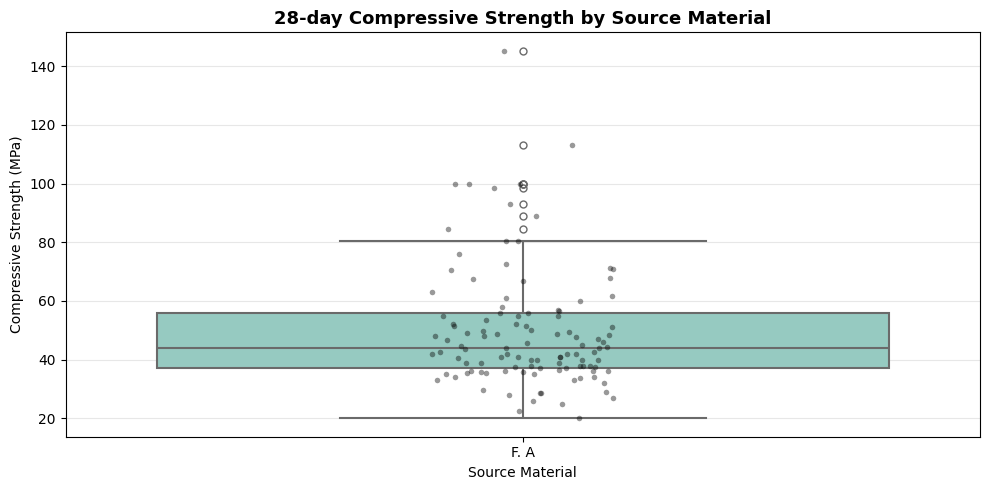

In [78]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df_eda.groupby('Source_material')['Compression_28d'].median().sort_values(ascending=False).index
sns.boxplot(data=df_eda, x='Source_material', y='Compression_28d', order=order,
            palette='Set3', ax=ax, linewidth=1.5, fliersize=5)
sns.stripplot(data=df_eda, x='Source_material', y='Compression_28d', order=order,
              color='black', alpha=0.4, size=4, jitter=True, ax=ax)
ax.set_title('28-day Compressive Strength by Source Material', fontsize=13, fontweight='bold')
ax.set_xlabel('Source Material'); ax.set_ylabel('Compressive Strength (MPa)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 🎻 5. Violin Plot – Compression by Alkali Solution

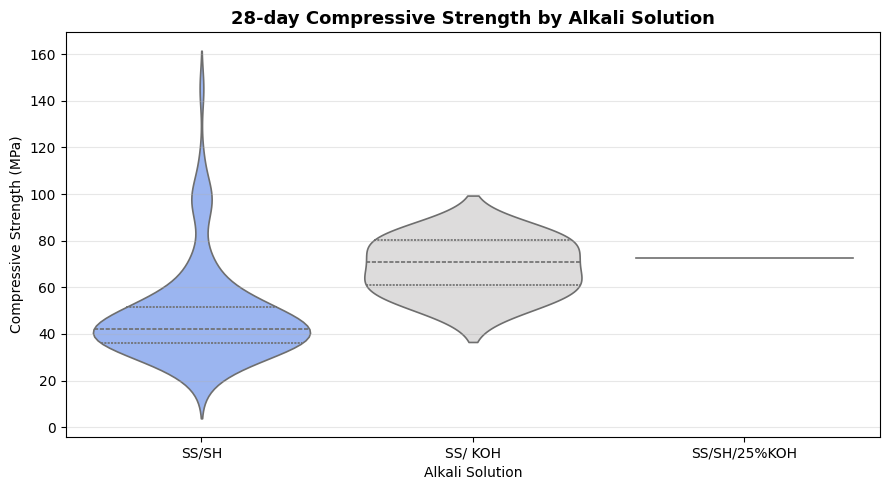

In [79]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df_eda, x='Alkali_solution', y='Compression_28d',
               palette='coolwarm', inner='quartile', linewidth=1.2, ax=ax)
ax.set_title('28-day Compressive Strength by Alkali Solution', fontsize=13, fontweight='bold')
ax.set_xlabel('Alkali Solution'); ax.set_ylabel('Compressive Strength (MPa)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 🔴 6. Molarity vs Compressive Strength (Scatter with Regression Line)

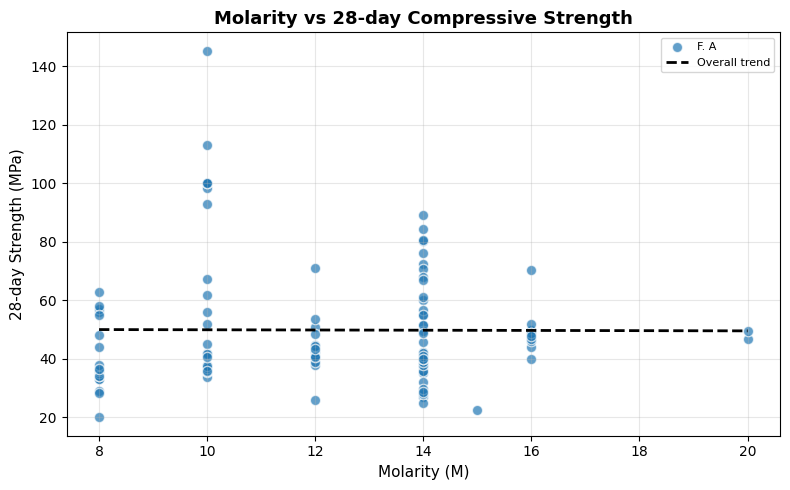

In [80]:
fig, ax = plt.subplots(figsize=(8, 5))
hue_col = 'Source_material'
for src, grp in df_eda.groupby(hue_col):
    ax.scatter(grp['Molarity'], grp['Compression_28d'], label=src, alpha=0.7, s=55, edgecolors='white')
# Overall trend line
from numpy.polynomial.polynomial import polyfit
sub = df_eda[['Molarity','Compression_28d']].dropna()
c = np.polyfit(sub['Molarity'], sub['Compression_28d'], 1)
xr = np.linspace(sub['Molarity'].min(), sub['Molarity'].max(), 200)
ax.plot(xr, np.polyval(c, xr), 'k--', linewidth=2, label='Overall trend')
ax.set_xlabel('Molarity (M)', fontsize=11); ax.set_ylabel('28-day Strength (MPa)', fontsize=11)
ax.set_title('Molarity vs 28-day Compressive Strength', fontsize=13, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 🌡️ 7. Pivot Heatmap – Average Strength by Molarity × Curing Temp

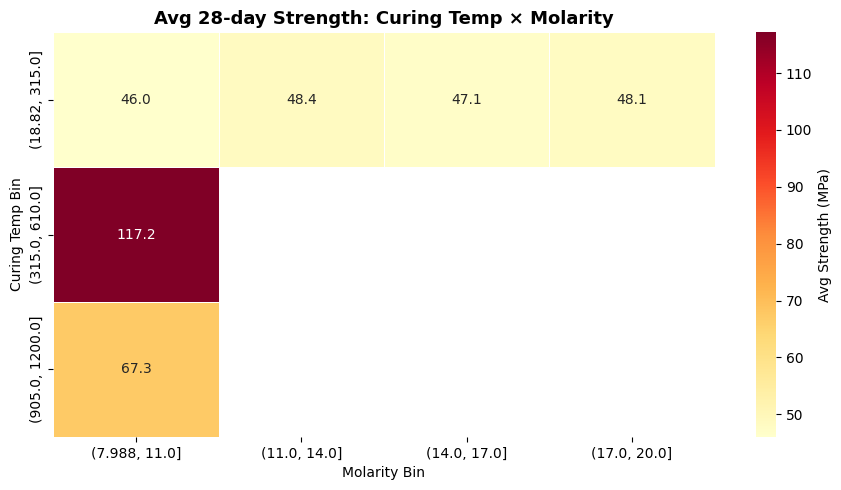

In [81]:
df_eda['Molarity_bin'] = pd.cut(df_eda['Molarity'], bins=4)
df_eda['Curing_bin']  = pd.cut(df_eda['Curing_temp'], bins=4)
pivot = df_eda.pivot_table(values='Compression_28d', index='Curing_bin',
                            columns='Molarity_bin', aggfunc='mean')
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Strength (MPa)'}, ax=ax)
ax.set_title('Avg 28-day Strength: Curing Temp × Molarity', fontsize=13, fontweight='bold')
ax.set_xlabel('Molarity Bin'); ax.set_ylabel('Curing Temp Bin')
plt.tight_layout()
plt.show()


### 🟢 8. Alkali/Binder Ratio vs Compressive Strength

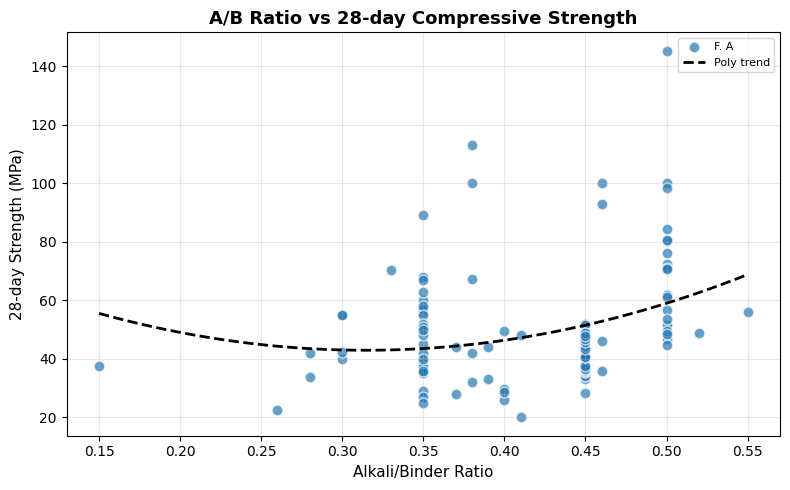

In [82]:
fig, ax = plt.subplots(figsize=(8, 5))
sub = df_eda[['A_B_ratio', 'Compression_28d', 'Source_material']].dropna()
for src, grp in sub.groupby('Source_material'):
    ax.scatter(grp['A_B_ratio'], grp['Compression_28d'], label=src, alpha=0.7, s=60, edgecolors='white')
c2 = np.polyfit(sub['A_B_ratio'], sub['Compression_28d'], 2)
xr2 = np.linspace(sub['A_B_ratio'].min(), sub['A_B_ratio'].max(), 300)
ax.plot(xr2, np.polyval(c2, xr2), 'k--', linewidth=2, label='Poly trend')
ax.set_xlabel('Alkali/Binder Ratio', fontsize=11); ax.set_ylabel('28-day Strength (MPa)', fontsize=11)
ax.set_title('A/B Ratio vs 28-day Compressive Strength', fontsize=13, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 🔷 9. SS/SH Ratio vs Compressive Strength (by Alkali Solution)

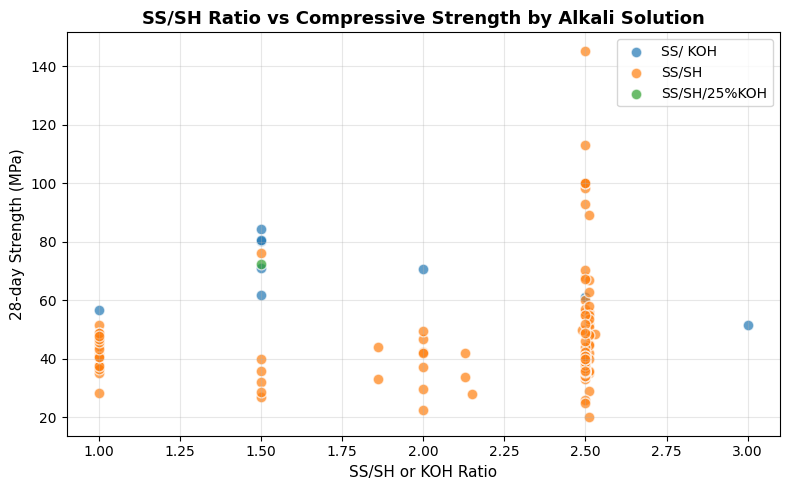

In [83]:
fig, ax = plt.subplots(figsize=(8, 5))
sub = df_eda[['SS_SH_KOH_ratio', 'Compression_28d', 'Alkali_solution']].dropna()
for sol, grp in sub.groupby('Alkali_solution'):
    ax.scatter(grp['SS_SH_KOH_ratio'], grp['Compression_28d'], label=sol, alpha=0.7, s=60, edgecolors='white')
ax.set_xlabel('SS/SH or KOH Ratio', fontsize=11)
ax.set_ylabel('28-day Strength (MPa)', fontsize=11)
ax.set_title('SS/SH Ratio vs Compressive Strength by Alkali Solution', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 🧪 10. Pivot Heatmap – Avg Strength by Source Material × Alkali Solution

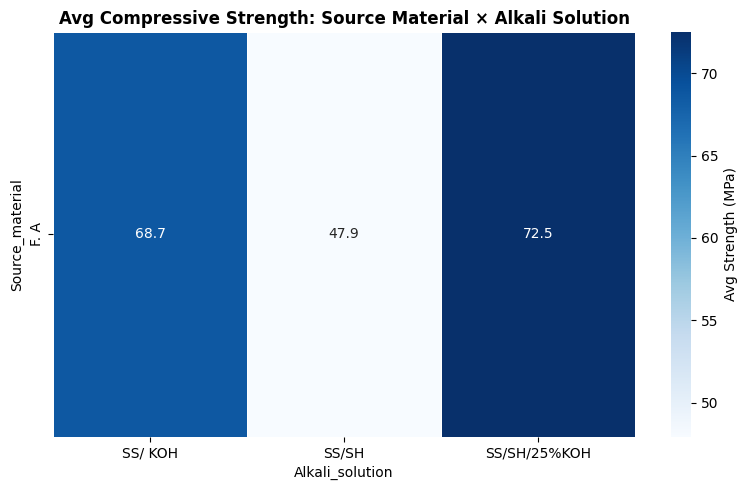

In [84]:
pivot2 = df_eda.pivot_table(values='Compression_28d',
                             index='Source_material',
                             columns='Alkali_solution',
                             aggfunc='mean')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Avg Strength (MPa)'}, ax=ax)
ax.set_title('Avg Compressive Strength: Source Material × Alkali Solution',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 📊 11. Mean Compressive Strength by Source Material (Bar Chart with Error Bars)

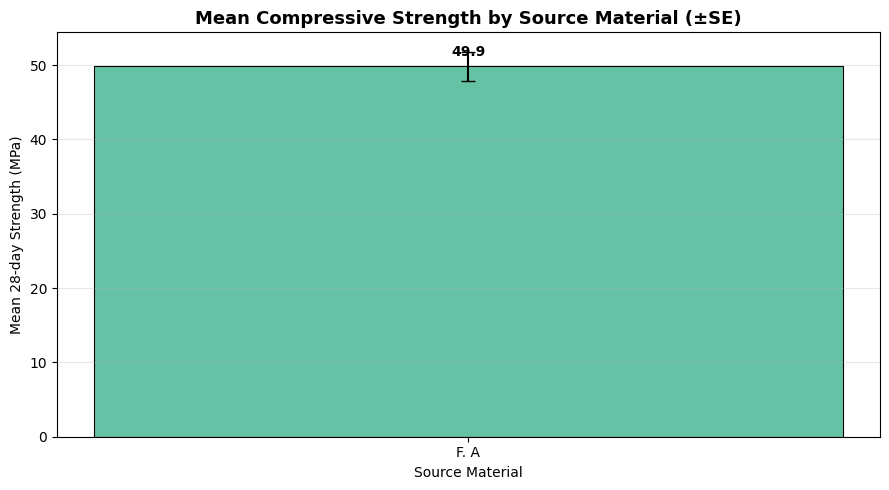

In [85]:
stats = df_eda.groupby('Source_material')['Compression_28d'].agg(['mean','std','count'])
stats['se'] = stats['std'] / stats['count']**0.5
stats = stats.sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('Set2', len(stats))
bars = ax.bar(stats.index, stats['mean'], yerr=stats['se'], capsize=5,
              color=colors, edgecolor='black', linewidth=0.8, error_kw={'elinewidth':1.5})
for bar, (_, row) in zip(bars, stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{row['mean']:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Source Material'); ax.set_ylabel('Mean 28-day Strength (MPa)')
ax.set_title('Mean Compressive Strength by Source Material (±SE)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 🎨 12. Scatter Matrix – Coloured by Source Material

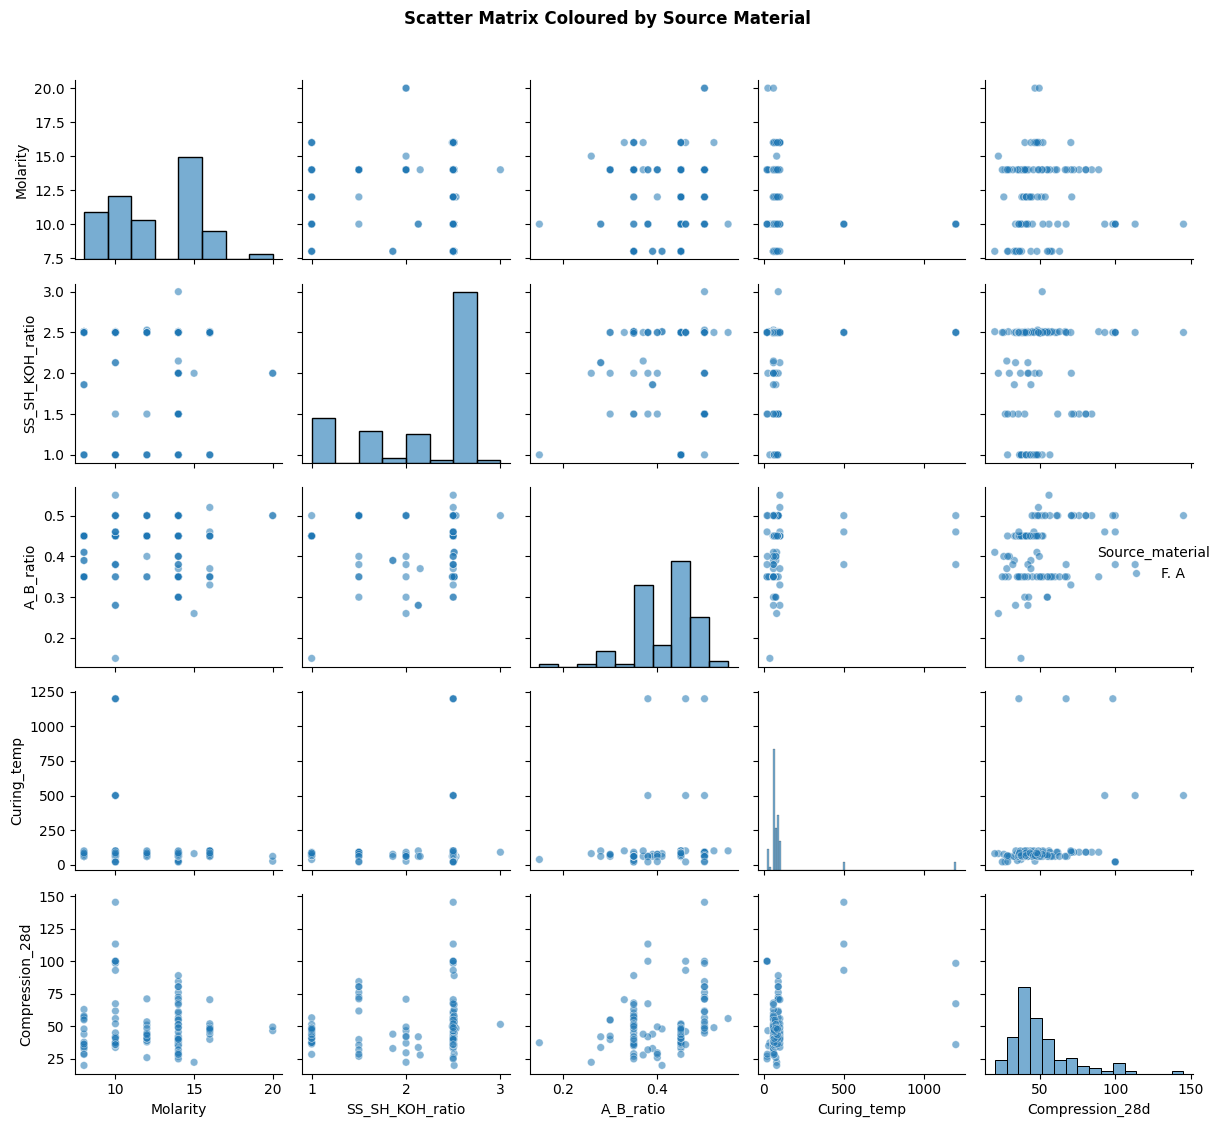

In [86]:
sub_sm = df_eda[num_cols + ['Source_material']].dropna()
g = sns.pairplot(sub_sm, hue='Source_material', diag_kind='hist',
                 plot_kws={'alpha': 0.55, 's': 30, 'edgecolors': 'white'},
                 diag_kws={'alpha': 0.6},
                 height=2.2)
g.figure.suptitle('Scatter Matrix Coloured by Source Material', y=1.02,
                   fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 🌡️ 13. Curing Temperature vs Compressive Strength

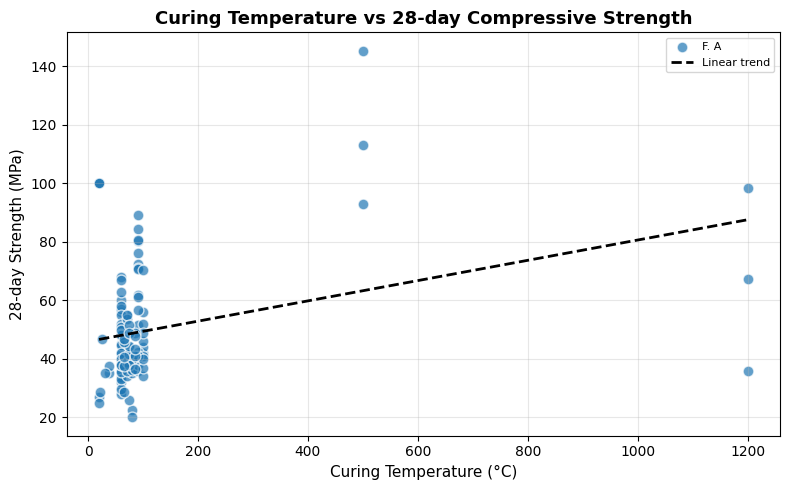

In [87]:
fig, ax = plt.subplots(figsize=(8, 5))
sub = df_eda[['Curing_temp', 'Compression_28d', 'Source_material']].dropna()
for src, grp in sub.groupby('Source_material'):
    ax.scatter(grp['Curing_temp'], grp['Compression_28d'], label=src,
               alpha=0.7, s=60, edgecolors='white')
c3 = np.polyfit(sub['Curing_temp'], sub['Compression_28d'], 1)
xr3 = np.linspace(sub['Curing_temp'].min(), sub['Curing_temp'].max(), 200)
ax.plot(xr3, np.polyval(c3, xr3), 'k--', linewidth=2, label='Linear trend')
ax.set_xlabel('Curing Temperature (°C)', fontsize=11)
ax.set_ylabel('28-day Strength (MPa)', fontsize=11)
ax.set_title('Curing Temperature vs 28-day Compressive Strength', fontsize=13, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 📦 14. Grouped Boxplot – Strength by Source Material × Alkali Solution

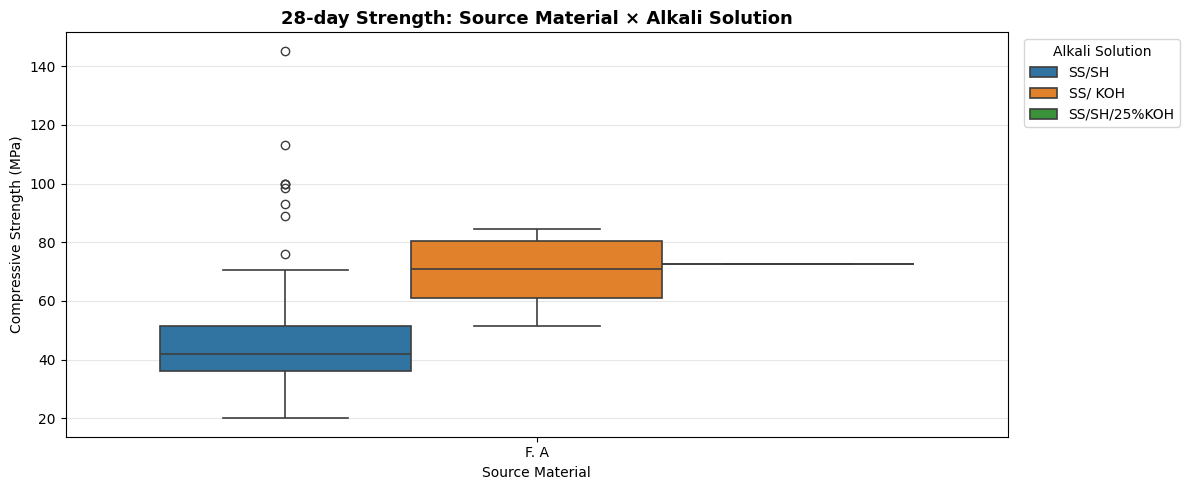

In [88]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_eda, x='Source_material', y='Compression_28d',
            hue='Alkali_solution', palette='tab10', ax=ax, linewidth=1.2)
ax.set_title('28-day Strength: Source Material × Alkali Solution', fontsize=13, fontweight='bold')
ax.set_xlabel('Source Material'); ax.set_ylabel('Compressive Strength (MPa)')
ax.legend(title='Alkali Solution', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 🔍 15. Missing Value Heatmap

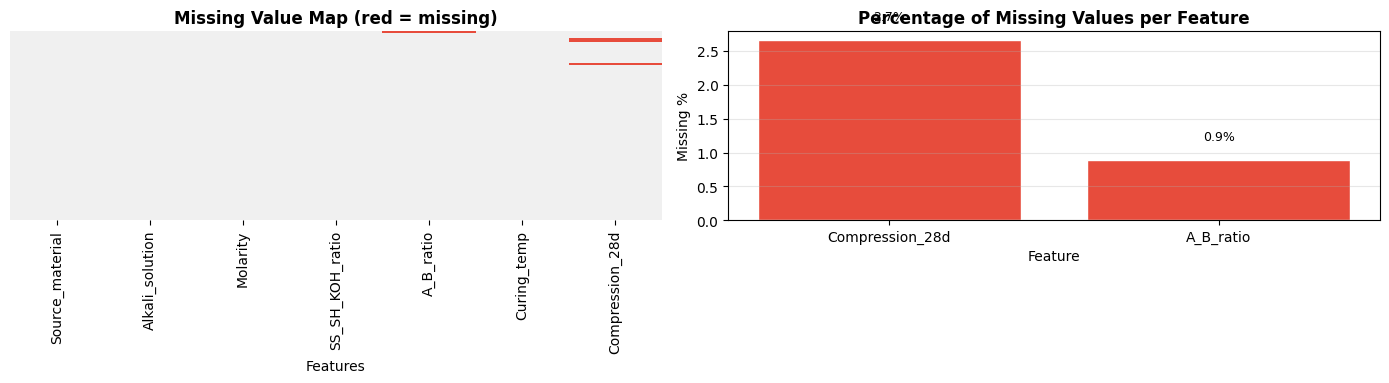

In [89]:
df_raw = pd.read_excel('excel1.xlsx')
for col in df_raw.select_dtypes(include='object').columns:
    df_raw[col] = df_raw[col].astype(str).str.strip()
df_raw = df_raw.replace(['--', '-', '—', ''], float('nan'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap of missingness
miss_matrix = df_raw.isnull().astype(int)
sns.heatmap(miss_matrix, ax=axes[0], cbar=False, yticklabels=False,
            cmap=['#f0f0f0', '#e74c3c'])
axes[0].set_title('Missing Value Map (red = missing)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Features')

# Bar chart of missing %
miss_pct = df_raw.isnull().mean() * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)
axes[1].bar(miss_pct.index, miss_pct.values, color='#e74c3c', edgecolor='white')
axes[1].set_ylabel('Missing %'); axes[1].set_xlabel('Feature')
axes[1].set_title('Percentage of Missing Values per Feature', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(miss_pct.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 🏆 16. Model Comparison – R² Score Bar Chart

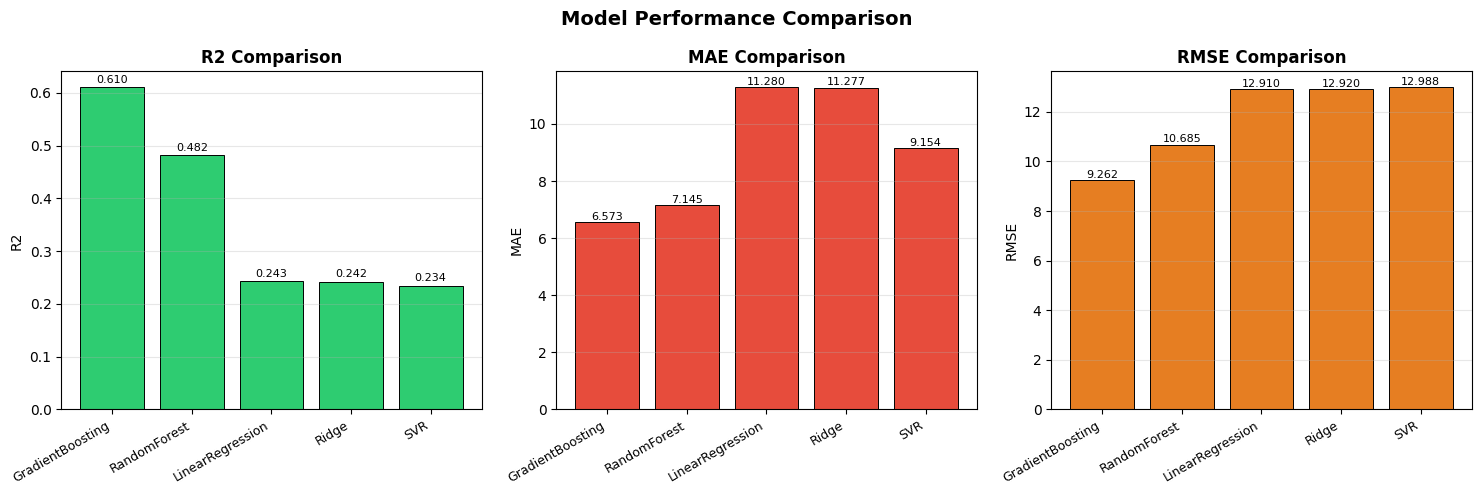

                        R2        MAE       RMSE
GradientBoosting  0.610440   6.573338   9.262294
RandomForest      0.481617   7.144668  10.684575
LinearRegression  0.243173  11.280381  12.910112
Ridge             0.242020  11.276851  12.919940
SVR               0.234060   9.154255  12.987605


In [90]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model_list = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'SVR': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}

results = {}
for name, m in model_list.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    results[name] = {
        'R2': r2_score(y_test, yp),
        'MAE': mean_absolute_error(y_test, yp),
        'RMSE': mean_squared_error(y_test, yp)**0.5
    }

res_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['R2', 'MAE', 'RMSE']
colors_m = ['#2ecc71', '#e74c3c', '#e67e22']
for ax, metric, clr in zip(axes, metrics, colors_m):
    bars = ax.bar(res_df.index, res_df[metric], color=clr, edgecolor='black', linewidth=0.7)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(res_df.index, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, res_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(res_df.to_string())


### 🌲 17. Random Forest Feature Importances

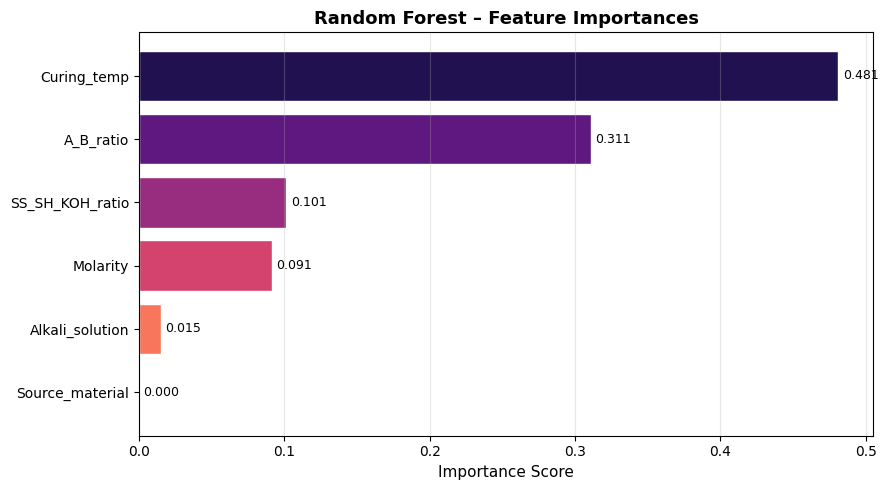

In [91]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

feature_names = list(X.columns)
importances = rf_model.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = sns.color_palette('magma', len(feature_names))
bars = ax.barh([feature_names[i] for i in idx], importances[idx],
                color=[colors_fi[i] for i in range(len(idx))], edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Random Forest – Feature Importances', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, importances[idx]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### 🚀 18. Gradient Boosting Feature Importances

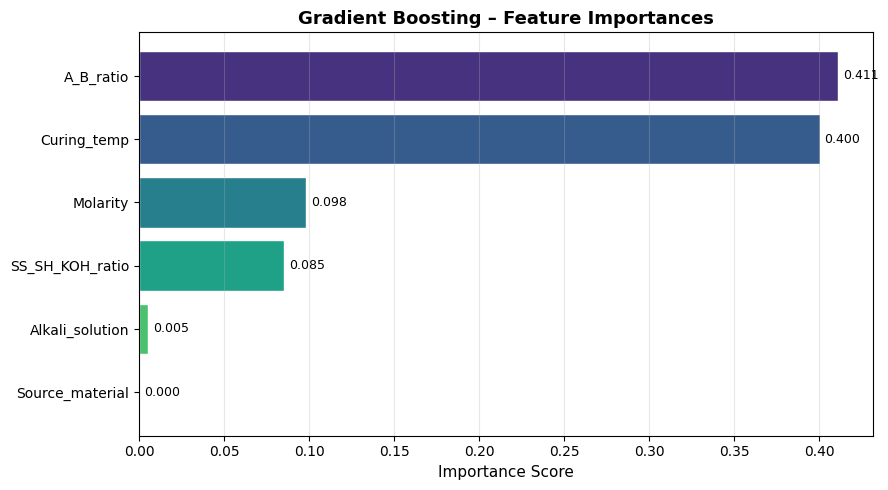

In [92]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

gb_importances = gb_model.feature_importances_
gb_idx = np.argsort(gb_importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
colors_gb = sns.color_palette('viridis', len(feature_names))
bars = ax.barh([feature_names[i] for i in gb_idx], gb_importances[gb_idx],
               color=[colors_gb[i] for i in range(len(gb_idx))], edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Gradient Boosting – Feature Importances', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, gb_importances[gb_idx]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### 📉 19. Residual Analysis (Best Model)

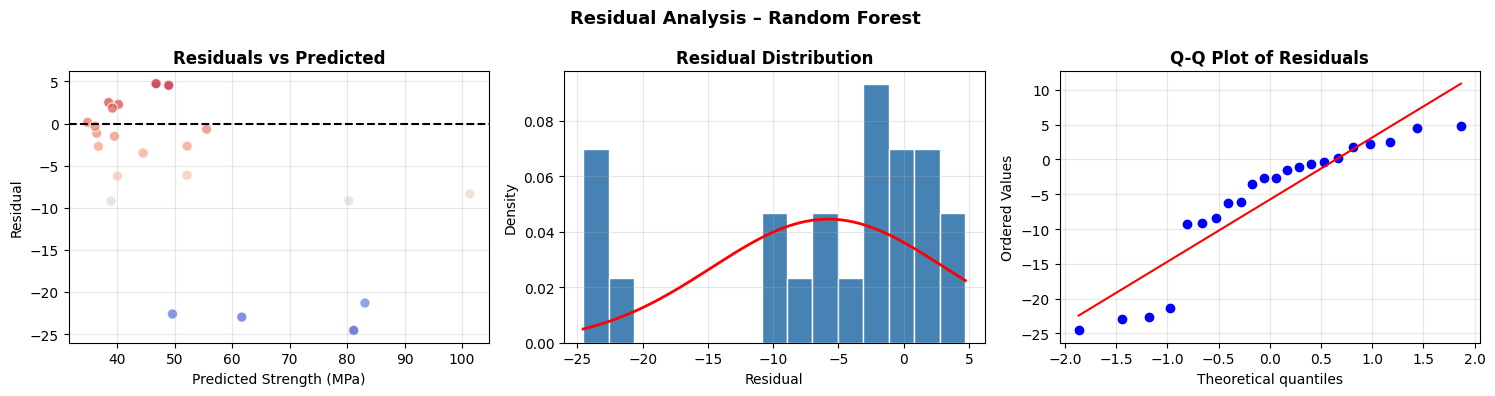

In [93]:
best_model = rf_model  # swap if needed
y_pred_best = best_model.predict(X_test)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.7, edgecolors='white', s=55,
               c=residuals, cmap='coolwarm')
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Strength (MPa)'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].grid(alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=15, color='steelblue', edgecolor='white', density=True)
from scipy.stats import norm
import scipy.stats as stats_module
mu, std = residuals.mean(), residuals.std()
xr_r = np.linspace(residuals.min(), residuals.max(), 200)
axes[1].plot(xr_r, norm.pdf(xr_r, mu, std), 'r-', linewidth=2)
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Density')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].grid(alpha=0.3)

# Q-Q plot
stats_module.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[2].grid(alpha=0.3)

fig.suptitle('Residual Analysis – Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 📊 20. Error Percentage Distribution Across All Models

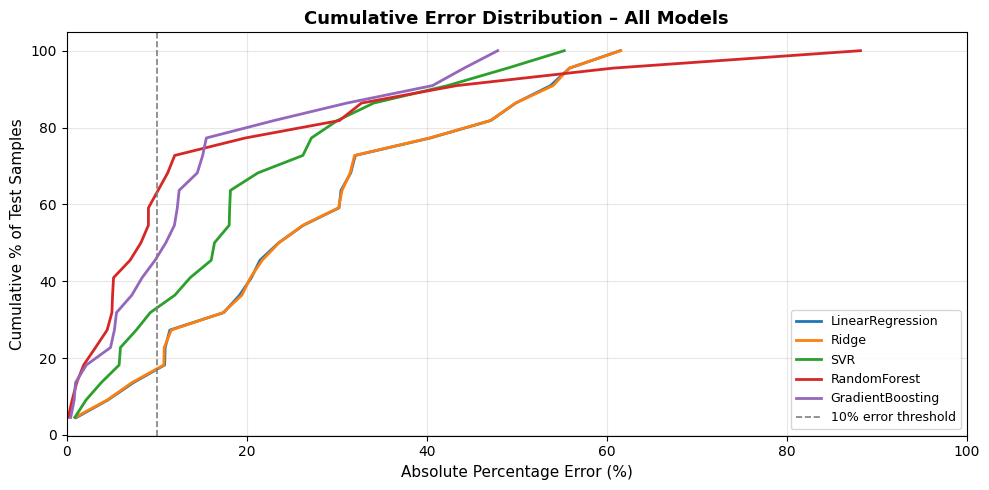

In [94]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, m in model_list.items():
    yp_m = m.predict(X_test)
    pct_err = np.abs(y_test.values - yp_m) / y_test.values * 100
    pct_err_sorted = np.sort(pct_err)
    cum = np.arange(1, len(pct_err_sorted)+1) / len(pct_err_sorted) * 100
    ax.plot(pct_err_sorted, cum, linewidth=2, label=name)

ax.axvline(10, color='grey', linestyle='--', linewidth=1.2, label='10% error threshold')
ax.set_xlabel('Absolute Percentage Error (%)', fontsize=11)
ax.set_ylabel('Cumulative % of Test Samples', fontsize=11)
ax.set_title('Cumulative Error Distribution – All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


### 🕸️ 21. Radar Chart – Normalised Model Metrics

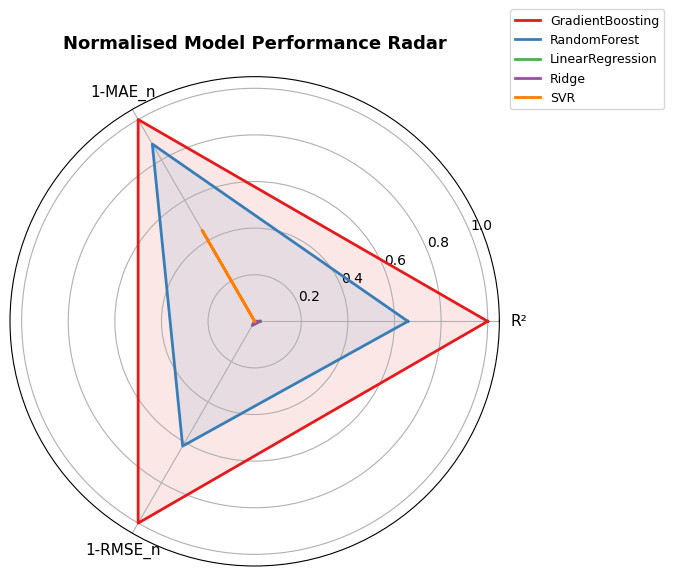

In [95]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics_radar = ['R2', 'MAE', 'RMSE']
# Normalise: higher R2 better, lower MAE/RMSE better → invert MAE/RMSE
max_r2   = res_df['R2'].max();  min_r2   = res_df['R2'].min()
max_mae  = res_df['MAE'].max(); min_mae  = res_df['MAE'].min()
max_rmse = res_df['RMSE'].max();min_rmse = res_df['RMSE'].min()

def norm(val, lo, hi, invert=False):
    n = (val-lo)/(hi-lo+1e-9)
    return 1-n if invert else n

cats = ['R²', '1-MAE_n', '1-RMSE_n']
N = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
palette_r = sns.color_palette('Set1', len(res_df))

for (name, row), clr in zip(res_df.iterrows(), palette_r):
    vals = [
        norm(row['R2'],   min_r2,   max_r2,   invert=False),
        norm(row['MAE'],  min_mae,  max_mae,  invert=True),
        norm(row['RMSE'], min_rmse, max_rmse, invert=True),
    ]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, linestyle='solid', label=name, color=clr)
    ax.fill(angles, vals, alpha=0.1, color=clr)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, size=11)
ax.set_title('Normalised Model Performance Radar', size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()


### 🔥 22. Pivot Heatmap – Average Strength by SS/SH Ratio × Molarity

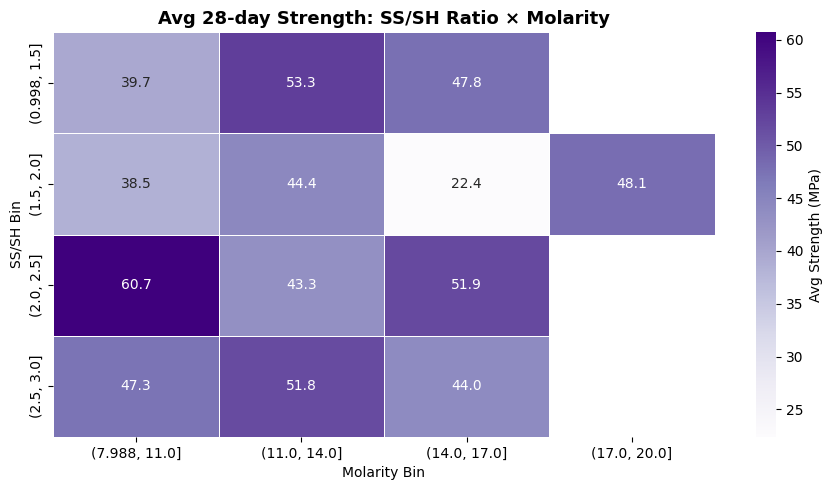

In [96]:
df_eda['SS_bin'] = pd.cut(df_eda['SS_SH_KOH_ratio'], bins=4)
df_eda['Mol_bin'] = pd.cut(df_eda['Molarity'], bins=4)
pivot3 = df_eda.pivot_table(values='Compression_28d', index='SS_bin',
                             columns='Mol_bin', aggfunc='mean')
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot3, annot=True, fmt='.1f', cmap='Purples', linewidths=0.5,
            cbar_kws={'label': 'Avg Strength (MPa)'}, ax=ax)
ax.set_title('Avg 28-day Strength: SS/SH Ratio × Molarity', fontsize=13, fontweight='bold')
ax.set_xlabel('Molarity Bin'); ax.set_ylabel('SS/SH Bin')
plt.tight_layout()
plt.show()


### 📈 23. Actual vs Predicted – All Models (Subplot Grid)

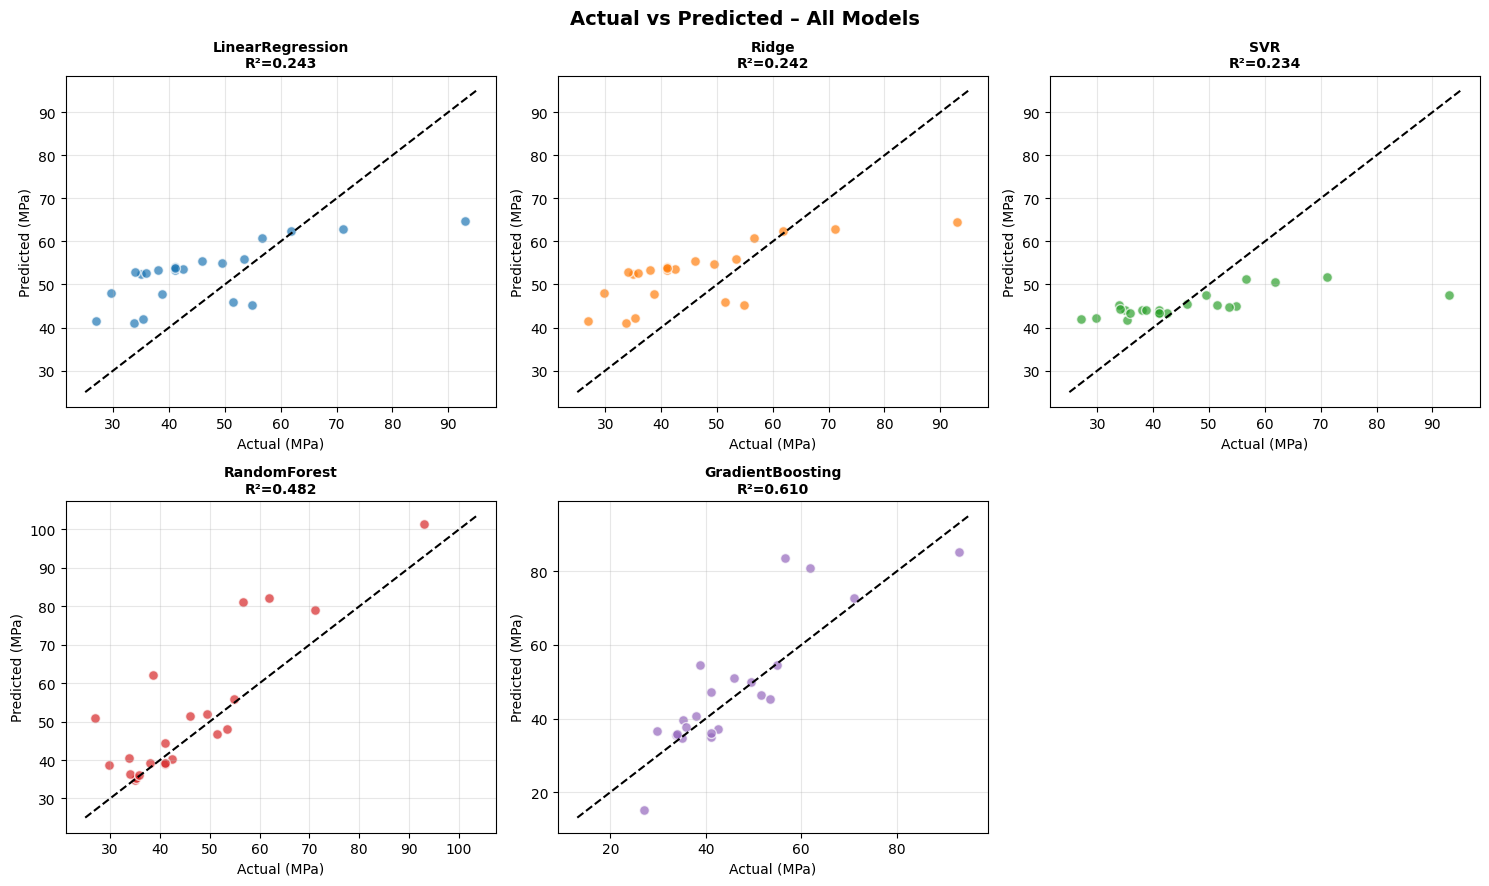

In [97]:
model_names = list(model_list.keys())
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
colors_avp = sns.color_palette('tab10', len(model_names))
for i, (name, m) in enumerate(model_list.items()):
    yp_i = m.predict(X_test)
    ax = axes[i]
    ax.scatter(y_test, yp_i, alpha=0.7, s=50, edgecolors='white',
               color=colors_avp[i], label=name)
    lims = [min(y_test.min(), yp_i.min())-2, max(y_test.max(), yp_i.max())+2]
    ax.plot(lims, lims, 'k--', linewidth=1.5)
    r2 = r2_score(y_test, yp_i)
    ax.set_title(f'{name}\nR²={r2:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual (MPa)'); ax.set_ylabel('Predicted (MPa)')
    ax.grid(alpha=0.3)
axes[-1].set_visible(False)
fig.suptitle('Actual vs Predicted – All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 🎻 24. Violin Plots for All Numeric Features

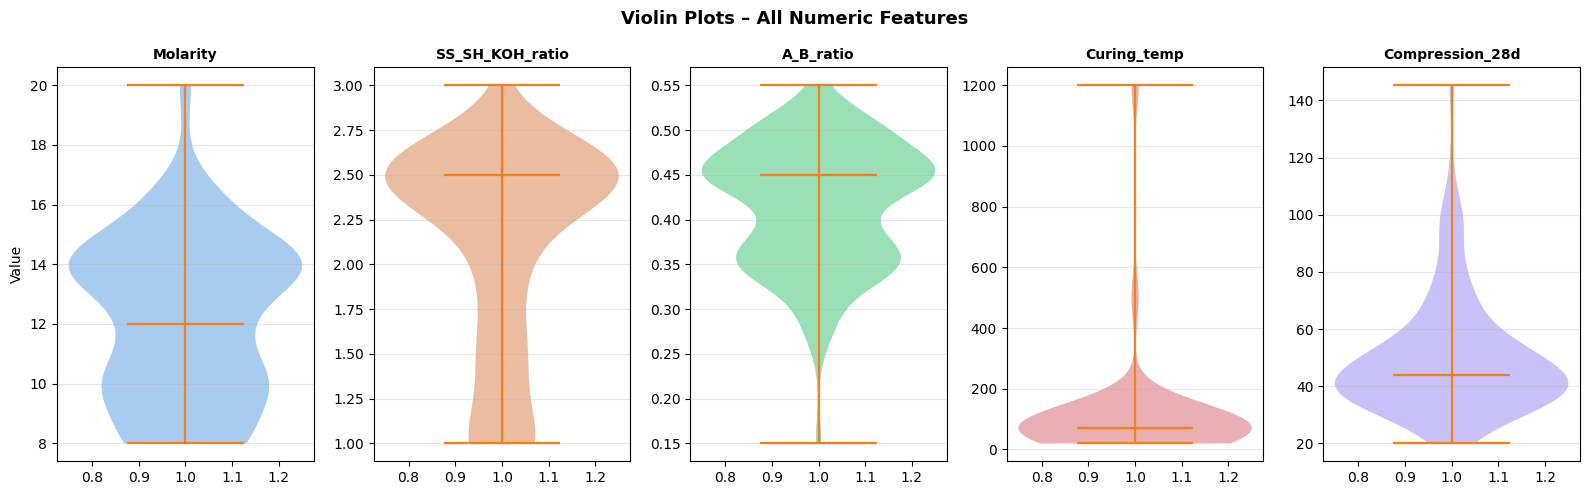

In [98]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 5))
palette_v = sns.color_palette('pastel', len(num_cols))
for ax, col, clr in zip(axes, num_cols, palette_v):
    data = df_eda[col].dropna()
    ax.violinplot(data, showmedians=True, showmeans=False)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value' if col == num_cols[0] else '')
    ax.grid(axis='y', alpha=0.3)
    parts = ax.violinplot(data, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(clr)
        pc.set_alpha(0.7)
fig.suptitle('Violin Plots – All Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 🗺️ 25. Clustermap (Hierarchical Clustering on Numeric Features)

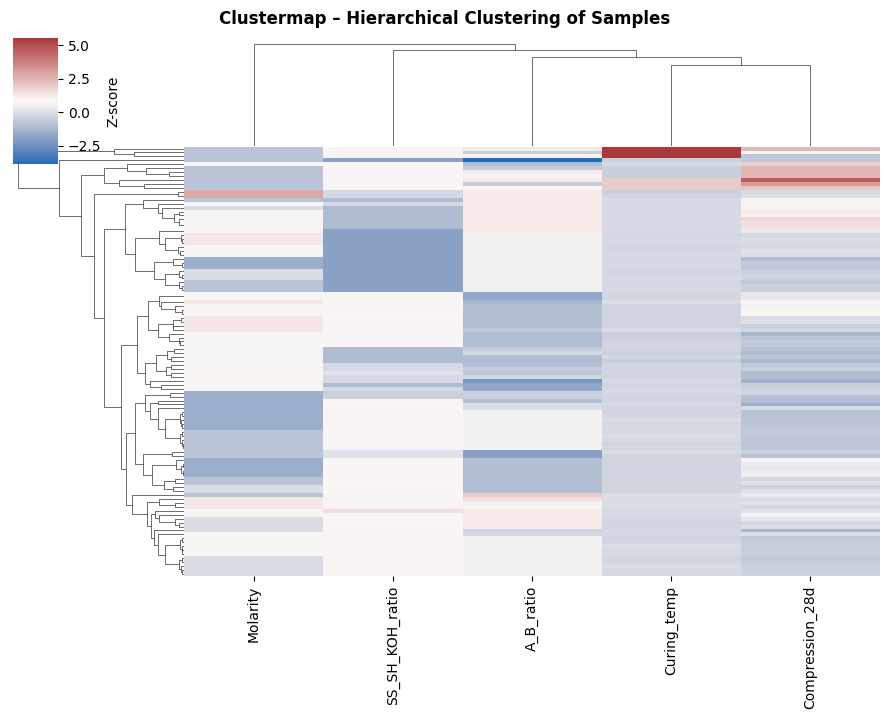

In [99]:
sub_cl = df_eda[num_cols].dropna()
from sklearn.preprocessing import StandardScaler as SC
sub_scaled = pd.DataFrame(SC().fit_transform(sub_cl), columns=num_cols)
g = sns.clustermap(sub_scaled, cmap='vlag', figsize=(9, 7),
                   row_cluster=True, col_cluster=True,
                   yticklabels=False, dendrogram_ratio=0.2,
                   cbar_kws={'label': 'Z-score'})
g.fig.suptitle('Clustermap – Hierarchical Clustering of Samples', fontsize=12,
               fontweight='bold', y=1.02)
plt.show()
